In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# Training data for NOT gate
x_train = np.array([[0.0], [1.0]], dtype=np.float32)
y_train = np.array([[1.0], [0.0]], dtype=np.float32)

In [20]:
# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=(1,), activation='sigmoid')
])

# Sigmoid activation function:
# σ(z) = 1 / (1 + exp(-z))

# For a perceptron:
# z = w * x + b
# σ(z) = 1 / (1 + exp(-(w * x + b)))

In [21]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [22]:
# Custom callback to print loss and weights/bias every epoch
class LossPrinter(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        weights = self.model.layers[0].get_weights()[0][0][0]
        bias = self.model.layers[0].get_weights()[1][0]
        print(f"Epoch {epoch+1:03d} - Loss: {logs['loss']:.4f} - Weight: {weights:.4f} - Bias: {bias:.4f}")

# Train and collect history
history = model.fit(x_train, y_train,
                    epochs=500,
                    verbose=0,
                    callbacks=[LossPrinter()])

Epoch 001 - Loss: 1.1594 - Weight: 1.3663 - Bias: -0.0152
Epoch 002 - Loss: 1.1411 - Weight: 1.3265 - Bias: -0.0297
Epoch 003 - Loss: 1.1233 - Weight: 1.2873 - Bias: -0.0436
Epoch 004 - Loss: 1.1061 - Weight: 1.2485 - Bias: -0.0568
Epoch 005 - Loss: 1.0894 - Weight: 1.2101 - Bias: -0.0695
Epoch 006 - Loss: 1.0732 - Weight: 1.1722 - Bias: -0.0815
Epoch 007 - Loss: 1.0576 - Weight: 1.1348 - Bias: -0.0929
Epoch 008 - Loss: 1.0424 - Weight: 1.0978 - Bias: -0.1037
Epoch 009 - Loss: 1.0277 - Weight: 1.0613 - Bias: -0.1139
Epoch 010 - Loss: 1.0134 - Weight: 1.0253 - Bias: -0.1235
Epoch 011 - Loss: 0.9996 - Weight: 0.9897 - Bias: -0.1325
Epoch 012 - Loss: 0.9863 - Weight: 0.9546 - Bias: -0.1410
Epoch 013 - Loss: 0.9733 - Weight: 0.9200 - Bias: -0.1489
Epoch 014 - Loss: 0.9608 - Weight: 0.8858 - Bias: -0.1562
Epoch 015 - Loss: 0.9487 - Weight: 0.8521 - Bias: -0.1630
Epoch 016 - Loss: 0.9369 - Weight: 0.8188 - Bias: -0.1693
Epoch 017 - Loss: 0.9255 - Weight: 0.7859 - Bias: -0.1750
Epoch 018 - Lo

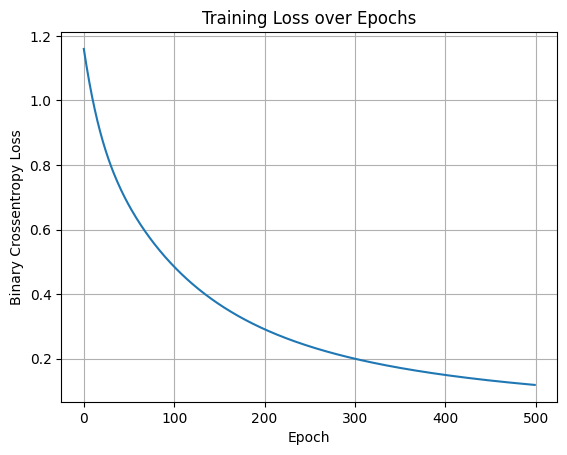

In [23]:

# Plot the loss curve
plt.plot(history.history['loss'])
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.grid(True)
plt.show()

In [24]:
# Show predictions
print("\nPredictions:")
for x in x_train:
    pred = model.predict(np.array([x]), verbose=0)
    print(f"Input: {x[0]} => Output: {np.round(pred[0][0])} (Raw: {pred[0][0]:.4f})")


Predictions:
Input: 0.0 => Output: 1.0 (Raw: 0.8654)
Input: 1.0 => Output: 0.0 (Raw: 0.0888)
